In [ ]:
import functools
import pathlib
import re
import warnings
from concurrent.futures import ThreadPoolExecutor

warnings.filterwarnings("ignore")

In [ ]:
import boto3
import botocore
from iterpop import iterpop as ip
import marimo as mo
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

from dishpylib.pyhelpers import fit_control_t_distns

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-10-01T12:15:57.058951+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

boto3   : 1.41.5
marimo  : 0.23.2
teeplot : 1.4.2
seaborn : 0.13.2
numpy   : 2.1.2
iterpop : 0.3.4
re      : 2.2.1
scipy   : 1.14.1
pandas  : 2.2.3
botocore: 1.41.5

```

# Phenotype Complexity Trajectories: Replays of Replicate 16005

Phenotype complexity is calculated on the fly (rather than through the full collation/processing system) as the number of cardinal interface sites (extrospective, introspective, and writable state exchanges plus inter- and intra-cell message self-sends) at which a perturbation is significantly deleterious (`Is Less Fit`), following the OEE4 binder notebook `2026-06-18-multistint-complexity`.
Replay buckets hold only uncollated (`stage=1+what=generated`) competition outputs, which are read directly; the original run (bucket `prq49`, series 16005) is read from collated outputs.
Each replay bucket is plotted in its own facet, with the trajectory of the original run shown in gray for reference.

In [ ]:
teeplot_subdir = pathlib.Path(__file__).stem

In [ ]:
original_bucket = "prq49"
replay_buckets = [
    "prq49-replay-stint014-rep000",
    "prq49-replay-stint014-rep001",
    "prq49-replay-stint014-rep002",
    "prq49-replay-stint014-rep003",
    "prq49-replay-stint014-rep004",
    "prq49-replay-stint015-rep000",
    "prq49-replay-stint015-rep001",
    "prq49-replay-stint015-rep002",
    "prq49-replay-stint015-rep003",
    "prq49-replay-stint015-rep004",
    "prq49-replay-stint016-rep000",
    "prq49-replay-stint016-rep001",
    "prq49-replay-stint016-rep002",
    "prq49-replay-stint016-rep003",
    "prq49-replay-stint016-rep004",
    "prq49-replay-stint020-rep000",
    "prq49-replay-stint020-rep001",
    "prq49-replay-stint020-rep002",
    "prq49-replay-stint020-rep003",
    "prq49-replay-stint020-rep004",
    "prq49-replay-stint030-rep000",
    "prq49-replay-stint030-rep001",
    "prq49-replay-stint030-rep002",
    "prq49-replay-stint030-rep003",
    "prq49-replay-stint030-rep004",
]
endeavor = 16
series = 16005

In [ ]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)

def list_stint_keys(bucket, prefix):
    # one collated file per stint
    bucket_handle = s3_handle.Bucket(bucket)
    return {
        int(re.search(r"/stint=(\d+)/", x.key).group(1)): x.key
        for x in bucket_handle.objects.filter(Prefix=prefix)
    }

@functools.lru_cache
def get_control_t_distns(bucket, control_key):
    control_df = pd.read_csv(f"s3://{bucket}/{control_key}")

    return fit_control_t_distns(
        control_df[control_df["Root ID"] == 1].copy()
    )

def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: scipy_stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 - 1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious"
                if row["Is Less Fit"]
                else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df

## Get Data

In [ ]:
whats = [
    "perturbation-extrospective-state-exchange-competitions",
    "perturbation-introspective-state-exchange-competitions",
    "perturbation-writable-state-exchange-competitions",
    "selfsend-inter-competitions",
    "selfsend-intra-competitions",
]

In [ ]:
def list_generated_keys(bucket, what):
    # one uncollated file per perturbed site
    bucket_handle = s3_handle.Bucket(bucket)
    keys = {}
    for x in bucket_handle.objects.filter(
        Prefix=f"endeavor={endeavor}/{what}/stage=1+what=generated/",
    ):
        if (
            f"/series={series}/" in x.key
            and "/a=coalescence_result" in x.key
            and x.key.endswith(".csv")
        ):
            stint = int(re.search(r"/stint=(\d+)/", x.key).group(1))
            keys.setdefault(stint, []).append(x.key)
    return keys

def tabulate_stint(bucket, stint, what, data_keys, control_key):
    if bucket == original_bucket:
        # collated: a single file per stint
        df = pd.read_csv(f"s3://{bucket}/{data_keys[0]}", compression="xz")
    else:
        df = pd.concat(
            [pd.read_csv(f"s3://{bucket}/{key}") for key in data_keys],
            ignore_index=True,
        )
    df = df[df["Competition Series"] == series].copy()
    control_fits_df = get_control_t_distns(bucket, control_key)
    df = preprocess_competition_fitnesses(df, control_fits_df)
    df = df[df["Root ID"] == 1]
    return {
        "bucket": bucket,
        "Stint": stint,
        "what": what,
        "Phenotype Complexity": df["Is Less Fit"].sum(),
        "Num Sites Tested": len(df),
    }

jobs = []
for bucket in [original_bucket, *replay_buckets]:
    control_keys = list_stint_keys(
        bucket,
        f"endeavor={endeavor}/control-competitions/stage=2+what=collated/",
    )
    for what in whats:
        if bucket == original_bucket:
            data_keys = {
                stint: [key]
                for stint, key in list_stint_keys(
                    bucket,
                    f"endeavor={endeavor}/{what}/stage=2+what=collated/",
                ).items()
            }
        else:
            data_keys = list_generated_keys(bucket, what)
        for stint, keys in sorted(data_keys.items()):
            if stint in control_keys:
                jobs.append((bucket, stint, what, keys, control_keys[stint]))

with ThreadPoolExecutor(max_workers=16) as pool:
    df_components = pd.DataFrame(
        pool.map(lambda args: tabulate_stint(*args), jobs)
    )

df_complexity = (
    df_components.groupby(["bucket", "Stint"])
    .agg(
        {
            "Phenotype Complexity": "sum",
            "Num Sites Tested": "sum",
            "what": "nunique",
        }
    )
    .rename(columns={"what": "Num Kinds"})
    .reset_index()
)

In [ ]:
df_complexity["replay"] = df_complexity["bucket"].str.replace(
    "prq49-replay-", "", regex=False
)
df_complexity.loc[
    df_complexity["bucket"] == original_bucket, "replay"
] = "original"

df_original = df_complexity[
    df_complexity["bucket"] == original_bucket
].copy()
df_replays = df_complexity[
    df_complexity["bucket"] != original_bucket
].copy()
df_replays["replay start"] = df_replays["replay"].str.extract(
    r"(stint\d+)"
)
df_replays["replicate"] = df_replays["replay"].str.extract(r"(rep\d+)")

In [ ]:
pd.concat([df_original.head(), df_replays.head(), df_replays.tail()])

,bucket,Stint,Phenotype Complexity,Num Sites Tested,Num Kinds,replay,replay start,replicate
0,prq49,0,2,164,5,original,NaN,NaN
1,prq49,1,2,164,5,original,NaN,NaN
2,prq49,2,7,164,5,original,NaN,NaN
3,prq49,3,2,164,5,original,NaN,NaN
4,prq49,4,4,163,5,original,NaN,NaN
...,...,...,...,...,...,...,...,...
286,prq49-replay-stint030-rep004,40,3,164,5,stint030-rep004,stint030,rep004
287,prq49-replay-stint030-rep004,45,5,164,5,stint030-rep004,stint030,rep004
288,prq49-replay-stint030-rep004,50,5,164,5,stint030-rep004,stint030,rep004
289,prq49-replay-stint030-rep004,55,7,164,5,stint030-rep004,stint030,rep004


## Original Trajectory (bucket `prq49`, series 16005)

teeplots/2026-10-01-replay-phenotype-complexity/kind=line+marker=o+viz=relplot+x=stint+y=phenotype-complexity+ext=.pdf
teeplots/2026-10-01-replay-phenotype-complexity/kind=line+marker=o+viz=relplot+x=stint+y=phenotype-complexity+ext=.png


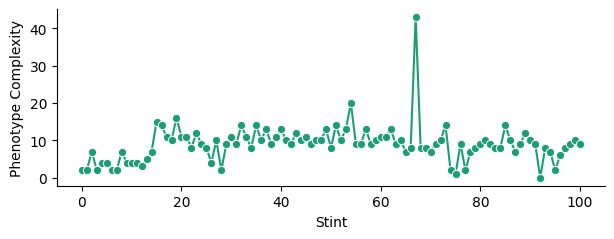

In [ ]:
with tp.teed(
    sns.relplot,
    data=df_original,
    x="Stint",
    y="Phenotype Complexity",
    kind="line",
    marker="o",
    color=sns.color_palette("Dark2")[0],
    height=2.5,
    aspect=2.5,
    teeplot_subdir=teeplot_subdir,
    teeplot_show=True,
) as _g:
    _g.set_titles("prq49 (original)")

## Replay Trajectories
Each facet is one replay bucket.
Points above the y-axis limit are flagged with a red triangle.
The original trajectory is underlaid in gray.

teeplots/2026-10-01-replay-phenotype-complexity/col=replay+kind=line+marker=o+viz=relplot+x=stint+y=phenotype-complexity+ext=.pdf
teeplots/2026-10-01-replay-phenotype-complexity/col=replay+kind=line+marker=o+viz=relplot+x=stint+y=phenotype-complexity+ext=.png


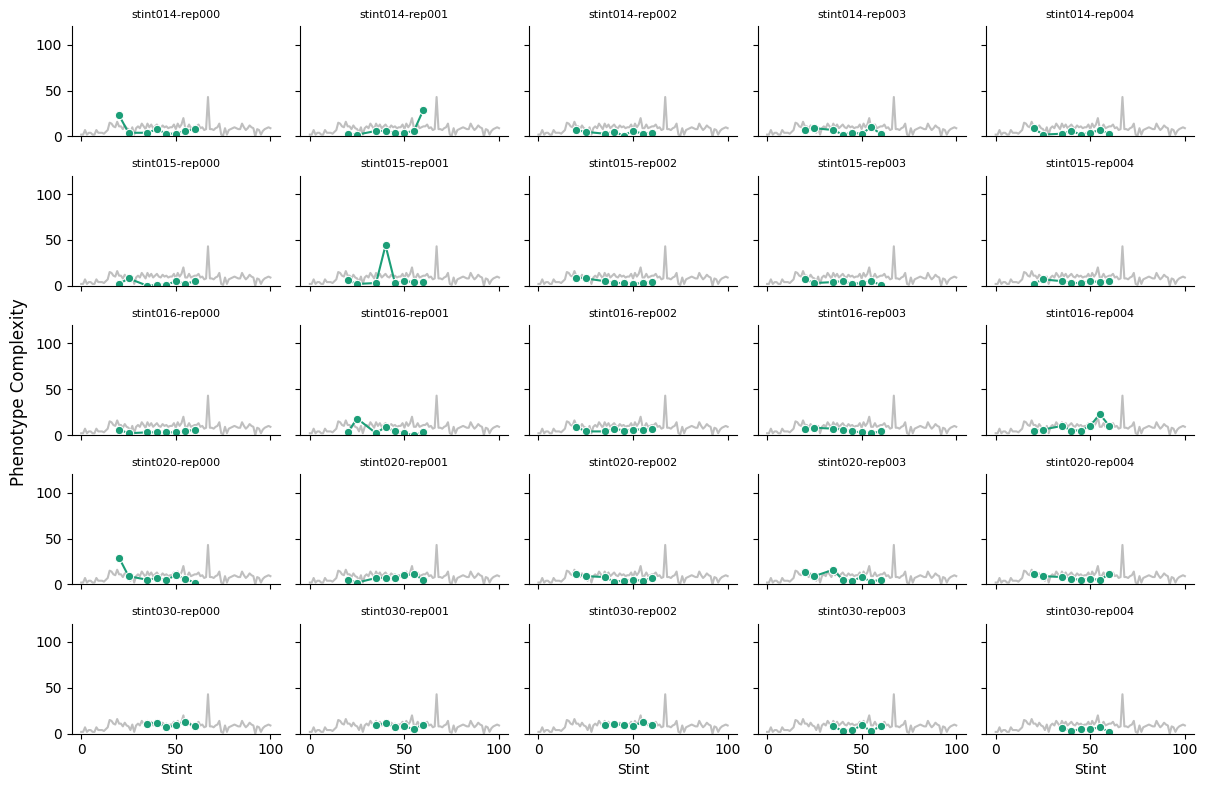

In [ ]:
ymax = 120  # outliers above this are flagged with a red triangle
with tp.teed(
    sns.relplot,
    data=df_replays,
    x="Stint",
    y="Phenotype Complexity",
    col="replay",
    col_wrap=5,
    kind="line",
    marker="o",
    color=sns.color_palette("Dark2")[0],
    height=1.6,
    aspect=1.5,
    teeplot_subdir=teeplot_subdir,
    teeplot_show=True,
) as _g:
    _g.set_titles("{col_name}", size=8)
    _g.set_axis_labels("Stint", "")
    _g.figure.supylabel("Phenotype Complexity", x=0.0, fontsize=12)
    for _name, _ax in _g.axes_dict.items():
        _ax.plot(
            df_original["Stint"],
            df_original["Phenotype Complexity"],
            color="0.75",
            zorder=-1,
        )
        _ax.set_ylim(0, ymax)
        _clipped = df_replays[
            (df_replays["replay"] == _name)
            & (df_replays["Phenotype Complexity"] > ymax)
        ]
        _ax.scatter(
            _clipped["Stint"],
            [ymax] * len(_clipped),
            marker="^",
            color="red",
            clip_on=False,
            zorder=3,
        )